In [6]:
import json
import math
import matplotlib.pyplot as plt

In [26]:
model_names = [
    # "LinearClassifier_scent_curriculum_250",
    # "LinearClassifier_scent_curriculum_500",
    "LinearClassifier_scent_curriculum",
    # "LinearClassifier_scent_curriculum_global",
    # "LinearClassifier_scent_curriculum_local",
    "LinearClassifier_scent_batch",
    "LinearClassifier_sox_batch",
    "LinearClassifier_sox_curriculum"
]

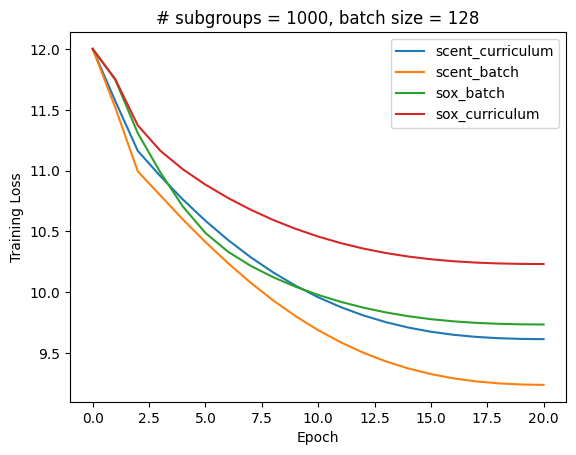

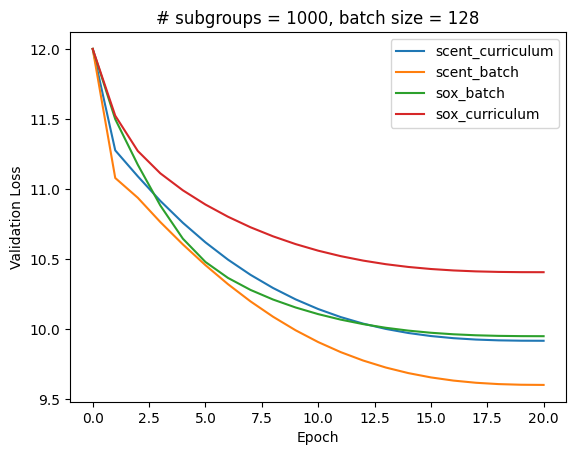

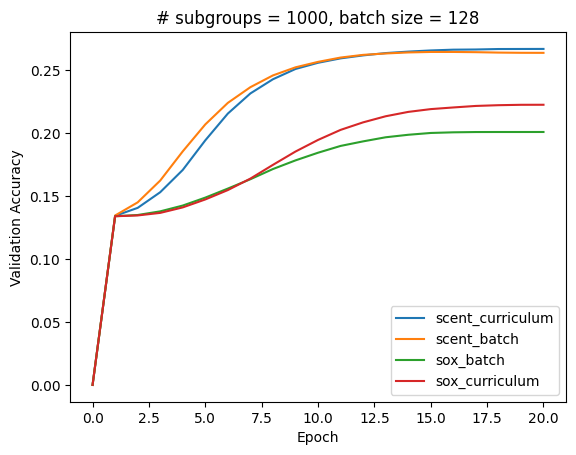

In [27]:
num_classes = 163002
for metric, name in zip(["cross_entropy_loss", "val_loss", "val_acc"], ["Training Loss", "Validation Loss", "Validation Accuracy"]):
    results = {model_name: {}}
    for model_name in model_names:


        if "loss" in metric:
            results[model_name] = [-math.log(1.0 / num_classes)] + [0.0] * 20
        else:
            results[model_name] = [1.0 / num_classes] + [0.0] * 20

        with open(f"./outputs/{model_name}/eval_{model_name}.jsonl", "r") as f:
            for line in f:
                eval_results = json.loads(line)
                results[model_name][eval_results["epoch"]] = eval_results[metric]

    fig, ax = plt.subplots()
    for model_name in model_names:
        ax.plot(results[model_name], label=model_name.replace("LinearClassifier_", ""))
    ax.set_xlabel("Epoch")
    ax.set_ylabel(name)
    ax.set_title('# subgroups = 1000, batch size = 128')
    ax.legend()

plt.show()
